In [95]:
# V4: dune toe based on curvature (x_toe), slope (x_toe2, x_toe3) with temporal smoothing before toe extraction (x_toe, x_toe2) and after (x_toe3) 
# v5: temporal filtering to remove noise, except when slumping occured
# v6: load all 16 profiles

import numpy as np 
import xarray as xr
import os   
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib as mpl
from matplotlib.collections import LineCollection
import colorcet as cc   # For color maps
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
from scipy.ndimage import uniform_filter1d
from netCDF4 import Dataset
import warnings

import sys
sys.path.append('../functions')
from convert_lidar_coordinates_ds_single import convert_lidar_coordinates_ds


In [34]:
## 1) FUNCTION TO LOAD AND FILTER LIDAR DATA
def filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=None, profile_isel=None, i_obs_start=361, i_obs_end=545):
    # Load pointcloud and convert to local coordinates. Filter cloud by deleting the mounting frame from the cloud, as well as high points that are waves/rain/...  
    # i_obs_start = 361  is straight under the lidar. i_obs_start = 545 for the later storms, when the dune toe is further seaward. i_obs_end = 545 # for 93deg

    # Define frame angles to be skipped
    # Initialize the array: shape (3, 2, 4, 3) for 3 skip_regions × 2 limits (start_stop) × 4 lidars × 3 storms
    hoek_frame_skip = np.zeros((3, 2, 4, 3))
    # S1
    hoek_frame_skip[:, :, 0, 0] = [[-17.4, -14.9], [-13.8, -10.9], [-2.75, 0]]   # storm 1
    hoek_frame_skip[:, :, 0, 1] = [[-16.9, -13.9], [-13.3, -9.9], [-2.25, 0.5]]  # storm 2
    hoek_frame_skip[:, :, 0, 2] = [[-17.4, -14.4], [-13.8, -10.9], [-2.75, 0]]   # storm 3

    # S2
    hoek_frame_skip[:, :, 1, 0] = [[-21.2, -18.2], [-14.3, -11.3], [-2.3, 0.7]]
    hoek_frame_skip[:, :, 1, 1] = [[-20.2, -17.7], [-13.8, -10.8], [-1.3, 1.7]]
    hoek_frame_skip[:, :, 1, 2] = [[-21.2, -18.2], [-14.3, -11.8], [-2.3, 0.7]]

    # S3
    hoek_frame_skip[:, :, 2, 0] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 1] = [[-17.0, -14.5], [-12.5, -9.5], [1.0, 4.0]]
    hoek_frame_skip[:, :, 2, 2] = [[-17.5, -14.5], [-12.5, -10.0], [0.5, 4.0]]

    # S4
    hoek_frame_skip[:, :, 3, 0] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 1] = [[-19.25, -16.25], [-11.25, -8.75], [-2.75, 0.25]]
    hoek_frame_skip[:, :, 3, 2] = [[-19.75, -16.75], [-11.75, -8.75], [-3.25, -0.25]]

        # # determine limits to load data from: which vertical angles to select. Between -90° and 105°
        # ds = xr.open_dataset(nc_in).isel(profile_number=0, t=0, echos=0)   # select specific time range: t0 until t_end

        # # # find obs_number with -90° < beam_angle < 105°
        # i_obs_start = np.where(ds.beam_angle.values > -90)[0][0]
        # i_obs_end = np.where(ds.beam_angle.values < 93)[0][-1]
        # print(i_obs_end)



    # load data with these obs_number limits
    if (t_sel is  None) and (profile_isel is None):
        ds = xr.open_dataset(nc_in).isel(obs_number=slice(i_obs_start, i_obs_end))                                            # select specific angles
    elif t_sel is None:
        ds = xr.open_dataset(nc_in).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))               # select specific angles and profile
    elif profile_isel is None:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(obs_number=slice(i_obs_start, i_obs_end))                               # select specific angles and time range
    else:
        ds = xr.open_dataset(nc_in).sel(t=t_sel).isel(profile_number=profile_isel, obs_number=slice(i_obs_start, i_obs_end))  # select specific angles, profile and time range

    # Filter out the frame -----------------------------------------------------------------------
    # Filter out the frame by replacing values in ds.beam_angle with NaN where the laser sees the frame. Then use filtered beam angles for coordinate conversion.

    # Select the slice for given n_lidar and n_storm (Python: 0-based)
    # Example: n_lidar = 1, n_storm = 2 (MATLAB) -> Python: 0, 1
    hoek_frame_skip_slice = hoek_frame_skip[:, :, n_lidar-1, n_storm-1] 

    # Filter frame: loop, for every row in hoek_frame_skip_slice, make angles nan where angles>value_col_1 and angles<value_col_2
    angles = ds.beam_angle.values

    for row in hoek_frame_skip_slice:
        angles[(angles > row[0]) & (angles < row[1])] = np.nan

    ds.beam_angle.values = angles   

    # Convert to local coordinates
    ds = convert_lidar_coordinates_ds(ds, 'local', max_echos=True, keep_I=True, keep_r=True, keep_y=False) # skip intensity, take max distance of echos

    # Define skip area (to remove points below x=6m and above z=-1m)
    x_skip_area = 6.5   # delete every point that is less than 6 m landward of lidar, and (simultaneously) less than 1 m below the lidar
    z_skip_area = -1
    x_min = ds.x_i_local.values + x_skip_area
    z_max = ds.z_i.values + z_skip_area

    # make x, y, z values nan where (x < x_skip_area) & (z > z_skip_area)
    mask_keep = (ds.x.values > x_min) | (ds.z.values < z_max) # keep where either condition is met. So remove where <x_lmin and >z_max
    # ds['x'] = ds.x.where(mask_keep)
    # ds['y'] = ds.y.where(mask_keep)
    # ds['z'] = ds.z.where(mask_keep)
    ds['radius_lidar'] = ds.radius_lidar.where(mask_keep)
    ds['intensity'] = ds.intensity.where(mask_keep)
    ds = ds.drop_vars(['x','z'])
    return ds


In [35]:
# 2) FUNCTION TO ITERATIVELY REMOVE SMALLEST VALUE AND CALCULATE MEAN
def filtered_mean_remove_smallest(windows_1, windows_2, std_thr=0.01, min_keep_frac=0.5):
    """
    Remove smallest values iteratively from windows_1 (along last axis) until std <= std_thr.
    Return filtered mean of windows_1 and mean of windows_2 over the same retained positions.

    Parameters
    ----------
    windows_1 : np.ndarray
        Any shape (..., L). Filtering is done along the last axis only.
    windows_2 : np.ndarray
        Same shape as windows_1. Mean is computed on the same retained positions.
    std_thr : float
        Threshold for population std (ddof=0), e.g. 0.01.
    min_keep_frac : float
        Minimum fraction of values that must remain. If fewer remain, output NaN.

    Returns
    -------
    out_1 : np.ndarray
        Shape windows_1.shape[:-1], containing filtered means of windows_1.
    out_2 : np.ndarray
        Shape windows_1.shape[:-1], containing means of windows_2 over retained positions.
    """
   
    W1_0 = np.asarray(windows_1, dtype=float)
    W2_0 = np.asarray(windows_2, dtype=float)
    if W1_0.ndim < 1:
        raise ValueError("`windows_1` must have at least 1 dimension.")
    if W1_0.shape != W2_0.shape:
        raise ValueError("`windows_1` and `windows_2` must have the same shape.")

    L = W1_0.shape[-1]
    leading_shape = W1_0.shape[:-1]
    N = int(np.prod(leading_shape)) if leading_shape else 1

    # Flatten only leading dims; keep last dim as window length
    W1 = W1_0.reshape(N, L)
    W2 = W2_0.reshape(N, L)

    valid1 = np.isfinite(W1)
    n_valid1 = valid1.sum(axis=1)

    # Sort once per window; NaNs -> +inf so they move to the end
    W1_sort = np.sort(np.where(valid1, W1, np.inf), axis=1)
    finite_sorted = np.isfinite(W1_sort)
    X1 = np.where(finite_sorted, W1_sort, 0.0)

    # Prefix sums (with leading zero)
    cs1 = np.concatenate([np.zeros((N, 1)), np.cumsum(X1, axis=1)], axis=1)
    cs1_2 = np.concatenate([np.zeros((N, 1)), np.cumsum(X1 * X1, axis=1)], axis=1)

    total1 = cs1[:, -1]
    total1_2 = cs1_2[:, -1]

    # k = number of removed smallest values
    k = np.arange(L + 1)[None, :]      # (1, L+1)
    m = n_valid1[:, None] - k           # remaining count after removing k smallest

    # Remaining sums after removing k smallest values (for windows_1)
    sum1_rem = total1[:, None] - cs1[:, :L+1]
    sum1sq_rem = total1_2[:, None] - cs1_2[:, :L+1]

    with np.errstate(invalid="ignore", divide="ignore"):
        mean1_rem = sum1_rem / m
        var1_rem = sum1sq_rem / m - mean1_rem * mean1_rem
    std1_rem = np.sqrt(np.maximum(var1_rem, 0.0))

    min_keep = int(np.ceil(min_keep_frac * L))
    good = (m >= min_keep) & np.isfinite(std1_rem) & (std1_rem <= std_thr)

    has_solution = good.any(axis=1)
    k_star = np.where(has_solution, good.argmax(axis=1), -1)

    out_1 = np.full(N, np.nan, dtype=float)
    out_2 = np.full(N, np.nan, dtype=float)
    rows = np.where(has_solution)[0]
    out_1[rows] = mean1_rem[rows, k_star[rows]]

    # windows_2 mean over the same retained positions as windows_1
    if rows.size > 0:
        order1 = np.argsort(np.where(valid1, W1, np.inf), axis=1)
        rank1 = np.empty_like(order1)
        rank1[np.arange(N)[:, None], order1] = np.arange(L)
        keep_mask = valid1 & (rank1 >= k_star[:, None])

        with np.errstate(invalid="ignore", divide="ignore"):
            num2 = np.where(keep_mask & np.isfinite(W2), W2, 0.0).sum(axis=1)
            den2 = (keep_mask & np.isfinite(W2)).sum(axis=1)
            mean2 = num2 / den2
        out_2[rows] = mean2[rows]

    return out_1.reshape(leading_shape), out_2.reshape(leading_shape)

In [36]:
## 3) LOAD AND FILTER LIDAR DATA
# INPUT PARAMETERS ------------------------------------------------------------------------------------------------
n_lidar = 2  # set as needed (1-based, like MATLAB)
i_obs_start_all = [420, 500, 420] # for 3 storms
for n_storm in [2]: #[1, 2, 3]:
#n_storm = 1 # set as needed (1-based, like MATLAB)

    nc_in = fr"C:\Users\dpoppema\OneDrive - Delft University of Technology\dataset_hybrid_dune\Lidar\data\S{n_lidar} Lidar, storm{n_storm}.nc"
    if n_storm == 1:
        t1 = pd.Timestamp('19-12-2024 02:02') # was 2:00
        t2 = pd.Timestamp('19-12-2024 22:00') # was 19dec 22:00
        # t1 = np.datetime64('2024-12-18T14:10:00.000000000')
        # t2 = pd.Timestamp('19-12-2024 02:02') # was 2:00
        #t2 = np.datetime64('2024-12-20T08:29:59.750000000')
    elif n_storm == 2:
        t1 = pd.Timestamp('22-12-2024 04:00')
        t2 = pd.Timestamp('22-12-2024 23:10')
        # t1 = pd.Timestamp('22-12-2024 16:30')
        # t2 = pd.Timestamp('22-12-2024 20:00')
        # t1 = pd.Timestamp('22-12-2024 07:00')
        # t2 = pd.Timestamp('22-12-2024 10:30')
    elif n_storm == 3:
        t1 = np.datetime64('2025-01-01T12:00')
        t2 = np.datetime64('2025-01-02T09:09')  # ensure that Jan 2 is selected, not Feb 1
    else:
        raise ValueError('n_storm must be 1, 2, or 3')

    # LOAD AND FILTER POINTCLOUD ----------------------------------------------------------------------------------------
    i_obs_start = i_obs_start_all[n_storm-1] # Python: 0-based indexing 
    i_profiles = 2#np.arange(16)  # select all 16 profiles
    ds = filter_pointcloud(nc_in, n_lidar, n_storm, t_sel=slice(t1, t2), profile_isel=i_profiles, i_obs_start=i_obs_start ) # Filter out frame and high waves (points less than 1 m below lidar and offshore of dune toe)  

In [37]:
# 04) MAKE T SPACING EXACTLY 0.25S 
def remap_to_uniform_time(ds_in, vars_to_remap=("radius_lidar", "intensity"), dt="250ms", time_dim="t"):
    t_old = pd.to_datetime(ds_in[time_dim].values)
    t_new = pd.date_range(
        t_old.min().ceil(dt),
        t_old.max().floor(dt),
        freq=dt
    )

    # For each old timestamp, find nearest new timestamp index
    idx = pd.Index(t_new).get_indexer(t_old, method="nearest")
    valid = idx >= 0

    # Keep non-time variables, then add new time coordinate
    ds_out = ds_in.drop_dims(time_dim).assign_coords({time_dim: t_new})

    for var in vars_to_remap:
        if var not in ds_in:
            continue

        da = ds_in[var]
        if time_dim not in da.dims:
            continue

        # Works for (obs_number, t) and (profile_number, obs_number, t), etc.
        lead_dims = tuple(d for d in da.dims if d != time_dim)
        da_tlast = da.transpose(*lead_dims, time_dim)
        arr = da_tlast.values  # shape: (..., n_old_t)

        out_shape = arr.shape[:-1] + (len(t_new),)
        out = np.full(out_shape, np.nan, dtype=np.result_type(arr.dtype, np.float32))

        # Fill nearest slots; if collisions happen, later samples overwrite earlier ones
        out[..., idx[valid]] = arr[..., valid]

        coords = {d: ds_in.coords[d] for d in lead_dims}
        coords[time_dim] = t_new

        ds_out[var] = xr.DataArray(out, dims=lead_dims + (time_dim,), coords=coords)

    return ds_out

ds = remap_to_uniform_time(ds, vars_to_remap=("radius_lidar", "intensity"), dt="250ms", time_dim="t")

# Recalculate x, z on updated time grid
ds = convert_lidar_coordinates_ds(ds, "local", max_echos=False, keep_I=True, keep_r=True, keep_y=False)

In [38]:
## 05) FILTER OVER 5s WINDOW

# Settings ------------------------------------------------------------------------------------------------------
sf = float(ds.sf.values)
if sf != 4.0:   # Temp code: sampling frequency of storm 2, lidar 2 is incorrect, at 0.1 Hz instead of 4 Hz
    warnings.warn(f"sf = {sf} instead of 4. Correct NetCDF! Using sf=4 for now")
    sf = 4
win_len = int(5 * sf)   # 5s in samples

# Build block windows by reshaping only the time dimension ------------------------------------------------------
time_dim = "t"
lead_dims = tuple(d for d in ds.radius_lidar.dims if d != time_dim)

r_da = ds.radius_lidar.transpose(*lead_dims, time_dim)
i_da = ds.intensity.transpose(*lead_dims, time_dim)
arr_r = r_da.values
arr_i = i_da.values

if arr_r.shape != arr_i.shape:
    raise ValueError("radius_lidar and intensity must have the same shape.")

lead_shape = arr_r.shape[:-1]
n_t = arr_r.shape[-1]

# number of complete windows and used samples
n_win = n_t // win_len # floor division to get number of complete windows
if n_win <= 0:
    raise ValueError("Not enough samples for a 5s window.")
n_t_used = n_win * win_len

# truncate trailing samples that do not fill a full window
arr_r = arr_r[..., :n_t_used]
arr_i = arr_i[..., :n_t_used]

# windows: (..., window, sample)
windows_r = arr_r.reshape(*lead_shape, n_win, win_len)
windows_i = arr_i.reshape(*lead_shape, n_win, win_len)

# filter v2: if std>1cm, iteratively remove smallest r until std<1cm.
# I is averaged over the exact same retained samples.
r_filter_v2, I_filter_v2 = filtered_mean_remove_smallest(  windows_r,  windows_i,  std_thr=0.01,  min_keep_frac=0.5  )

# center times for each window
t_vals = pd.to_datetime(ds.t.values[:n_t_used])
center_idx = np.arange(n_win) * win_len + win_len // 2
t_center = t_vals[center_idx].round("0.5s")

# wrap back to xarray
coords_lead = {d: ds.coords[d] if d in ds.coords else np.arange(ds.sizes[d]) for d in lead_dims}
coords_out = {**coords_lead, time_dim: t_center}
dims_out = lead_dims + (time_dim,)

r_filter_v2 = xr.DataArray(r_filter_v2, dims=dims_out, coords=coords_out)
I_filter_v2 = xr.DataArray(I_filter_v2, dims=dims_out, coords=coords_out)

# Save result to Xarray Dataset --------
# Define a new ds_profiles: a copy of ds, without the coordinate t, and with r_final as radius_lidar
ds_filter_v2 = ds.drop_dims(time_dim)  # drop t dimension

ds_filter_v2["radius_lidar"] = r_filter_v2  # Assign r_final as the new radius_lidar. Var name must be radius_lidar for convert_lidar_coordinates_ds
ds_filter_v2["intensity"] = I_filter_v2      # Intensity mean over the same retained samples as radius_lidar

ds_filter_v2 = convert_lidar_coordinates_ds(ds_filter_v2, 'local', max_echos=False, keep_I=True, keep_r=False, keep_y=True) # skip intensity. Max echos already taken, not needed again

C:\Users\dpoppema\AppData\Local\Temp\ipykernel_5724\2133386272.py:6: UserWarning: sf = 0.1 instead of 4. Correct NetCDF! Using sf=4 for now
  warnings.warn(f"sf = {sf} instead of 4. Correct NetCDF! Using sf=4 for now")


In [39]:
# 6) FILTER V3: REMOVE ALL PROFILES WITH x_start>minimum or ΔL>0.5m.
# Criterium 1) the first nonnan value of x > 792 or 796
# Criterium 2) the largest difference dL (dx^2 + dz^2)^(1/2) between consecutive points exceeds 0.5 m

ds_filter_v3 = ds_filter_v2.copy(deep=True)
dL_max = 0.5

# settings
if n_storm == 1 | n_lidar == 1 | n_lidar == 3: # for lidar 1, lidar 3 and all lidars in storm 1, use 792
    x_min = 792
else: # for S2 and S4, use 796 from storm 2 on
    x_min = 796

obs_dim = "obs_number"
time_dim = "t"
other_dims = tuple(d for d in ds_filter_v3.x.dims if d not in (obs_dim, time_dim))

# Reorder so we can evaluate each (other_dims, t) profile along obs_number
x_da = ds_filter_v3.x.transpose(*other_dims, obs_dim, time_dim)
z_da = ds_filter_v3.z.transpose(*other_dims, obs_dim, time_dim)
x_arr = x_da.values
z_arr = z_da.values

other_shape = x_arr.shape[:-2]
n_obs = x_arr.shape[-2]
n_t = x_arr.shape[-1]
N_other = int(np.prod(other_shape)) if other_shape else 1

# Flatten to cases: each row is one profile at one time step, over obs_number
x_cases = x_arr.reshape(N_other, n_obs, n_t).transpose(0, 2, 1).reshape(-1, n_obs)
z_cases = z_arr.reshape(N_other, n_obs, n_t).transpose(0, 2, 1).reshape(-1, n_obs)

bad_case = np.zeros(x_cases.shape[0], dtype=bool)

for k in range(x_cases.shape[0]):
    x = x_cases[k]
    z = z_cases[k]

    # extract non_nan values
    non_nan_mask = np.isfinite(x) & np.isfinite(z)
    x_non_nan = x[non_nan_mask]
    z_non_nan = z[non_nan_mask]

    if x_non_nan.size == 0:
        continue
    if x_non_nan[0] > x_min:
        bad_case[k] = True
        continue

    mask_keep = (x_non_nan > x_min) & (z_non_nan < 4.5)  # keep points that are landward of 796 and below the crest
    mask_keep[:-1] |= mask_keep[1:]       # set previous neighbour true where next is true: keep last point before x=796
    mask_keep[1:] |= mask_keep[:-1]       # set next neighbour true where previous is true: keep last point after z=4.5

    z_region_of_interest = z_non_nan[mask_keep]  # extract landward points
    x_region_of_interest = x_non_nan[mask_keep]  # extract landward points

    if x_region_of_interest.size < 2:
        continue

    dL = np.sqrt(np.diff(x_region_of_interest) ** 2 + np.diff(z_region_of_interest) ** 2)
    if np.max(dL) > dL_max:
        bad_case[k] = True

# Back to shape (..., t), then broadcast over obs_number when masking variables
bad_other_t = bad_case.reshape(N_other, n_t).reshape(other_shape + (n_t,))
coords_bad = {d: ds_filter_v3.coords[d] for d in other_dims}
coords_bad[time_dim] = ds_filter_v3.coords[time_dim]
bad_da = xr.DataArray(bad_other_t, dims=other_dims + (time_dim,), coords=coords_bad)

# Apply mask to all profile variables
keep_da = ~bad_da
for var_name in ["x", "y", "z", "intensity"]:
    ds_filter_v3[var_name] = ds_filter_v3[var_name].where(keep_da)

In [40]:
# 7) RESAMPING: SELECT ONLY NON-NAN OBSERVATIONS
def resample_nearest_non_nan(ds_in, valid_var="x", vars_2d=None, dt=np.timedelta64(30, "s"), max_gap=None, time_dim="t"):
    """
    Resample along time by picking, for each leading-dimension index, the nearest timestamp
    where valid_var is non-NaN.
    """
    if vars_2d is None:
        vars_2d = [valid_var, "y", "z", "intensity"]

    if valid_var not in ds_in:
        raise ValueError(f"Variable '{valid_var}' not found in dataset.")

    if time_dim not in ds_in[valid_var].dims:
        raise ValueError(f"time_dim '{time_dim}' not found in variable '{valid_var}'.")

    # source times
    source_time = ds_in[time_dim].values.astype("datetime64[ns]")      # original time stamps
    source_time_ns = source_time.astype(np.int64)                      # same times in integer ns (fast distance math)

    # target regular time grid
    start_time = source_time[0]                                        # first source timestamp
    end_time = source_time[-1]                                         # last source timestamp
    target_time = np.arange(start_time, end_time + dt, dt)             # regular output grid
    target_time_ns = target_time.astype(np.int64)                      # target times in integer ns

    # Build valid mask in canonical order (..., t), where ... are all non-time dims of valid_var
    lead_dims = tuple(d for d in ds_in[valid_var].dims if d != time_dim)
    valid_arr = np.isfinite(ds_in[valid_var].transpose(*lead_dims, time_dim).values)

    lead_shape = valid_arr.shape[:-1]
    n_t = valid_arr.shape[-1]
    n_target = target_time.size
    N = int(np.prod(lead_shape)) if lead_shape else 1

    # Flatten leading dims: each row is one leading-index combination over time
    valid_2d = valid_arr.reshape(N, n_t)

    # selected source index per (flat_row, target_time); -1 means no valid match
    selected_src_idx_2d = np.full((N, n_target), -1, dtype=int)

    # choose nearest valid source time for each leading-index row independently
    for row in range(N):
        valid_source_idx = np.flatnonzero(valid_2d[row])         # source t-indices where valid_var is finite
        if valid_source_idx.size == 0:
            continue

        valid_source_time_ns = source_time_ns[valid_source_idx]
        insert_pos = np.searchsorted(valid_source_time_ns, target_time_ns, side="left")

        left_pos = np.clip(insert_pos - 1, 0, valid_source_idx.size - 1)
        right_pos = np.clip(insert_pos, 0, valid_source_idx.size - 1)

        dist_left = np.abs(target_time_ns - valid_source_time_ns[left_pos])
        dist_right = np.abs(valid_source_time_ns[right_pos] - target_time_ns)

        choose_right = dist_right < dist_left
        chosen_pos = np.where(choose_right, right_pos, left_pos)

        selected_src_idx_2d[row, :] = valid_source_idx[chosen_pos]

    # optional: reject matches that are too far away in time
    if max_gap is not None:
        max_gap_ns = pd.to_timedelta(max_gap).to_timedelta64().astype("timedelta64[ns]").astype(np.int64)
        valid_pick = selected_src_idx_2d >= 0
        row_idx, col_idx = np.where(valid_pick)
        picked_dist_ns = np.abs(source_time_ns[selected_src_idx_2d[row_idx, col_idx]] - target_time_ns[col_idx])

        too_far = picked_dist_ns > max_gap_ns
        selected_src_idx_2d[row_idx[too_far], col_idx[too_far]] = -1

    # reshape selected indices back to (..., t_target)
    selected_src_idx = selected_src_idx_2d.reshape(lead_shape + (n_target,))

    # build output dataset on target grid
    ds_out = ds_in.drop_dims(time_dim).assign_coords({time_dim: target_time})

    # copy selected values into output variables (only vars with same leading dims as valid_var)
    for var_name in vars_2d:
        if var_name not in ds_in:
            continue

        var_data = ds_in[var_name]
        if time_dim not in var_data.dims:
            continue

        var_lead_dims = tuple(d for d in var_data.dims if d != time_dim)
        if var_lead_dims != lead_dims:
            continue

        var_arr = var_data.transpose(*lead_dims, time_dim).values.reshape(N, n_t)
        out_values_2d = np.full((N, n_target), np.nan, dtype=float)

        valid_pick = selected_src_idx_2d >= 0
        row_idx, col_idx = np.where(valid_pick)
        out_values_2d[row_idx, col_idx] = var_arr[row_idx, selected_src_idx_2d[row_idx, col_idx]]

        coords_out = {d: ds_in.coords[d] if d in ds_in.coords else np.arange(ds_in.sizes[d]) for d in lead_dims}
        coords_out[time_dim] = target_time
        ds_out[var_name] = xr.DataArray(
            out_values_2d.reshape(lead_shape + (n_target,)),
            dims=lead_dims + (time_dim,),
            coords=coords_out,
        )

    return ds_out, selected_src_idx


    # Run resampling: nearest non-NaN x per leading-index row on a 30 s grid
ds_filter_v3_30s, src_idx_30s = resample_nearest_non_nan(
    ds_in=ds_filter_v3,
    valid_var="x",
    vars_2d=["x", "y", "z", "intensity"],
    dt=np.timedelta64(30, "s"),
    # max_gap=np.timedelta64(60, "s")  # set to None if you do not want a distance limit
    max_gap=None,
    time_dim="t",
)

In [41]:
#  8) TOE ESTIMATION BASED ON SLOPE

# Estimate toe location based on slope, generalized for leading dims (..., obs_number, t).
# Settings ---------------------------------------------------------------------------------------
x_da = ds_filter_v3_30s.x
z_da = ds_filter_v3_30s.z

time_dim = "t"
obs_dim = "obs_number"
lead_dims = tuple(d for d in x_da.dims if d not in (obs_dim, time_dim))

# Reorder to (..., obs_number, t)
x_vals = x_da.transpose(*lead_dims, obs_dim, time_dim).values
z_vals = z_da.transpose(*lead_dims, obs_dim, time_dim).values

minutes_smoothing = 5  # in minutes, for Gaussian smoothing over time. Set to 0 to skip
dt_minutes = 0.5  # time step between profiles

# Define elevation range for toe search [m NAP]
z_min_toe = 1.8
z_max_toe = 3.5
x_max_crest = 801
if n_storm > 3:
    raise ValueError("crest estimation: check x_max_crest, may be >801 for sandy dune.")

# Target spacing along the arc length [m]
dl_target = 0.05  # [m]
dl_smoothing = 0.2  # [m], Gaussian smoothing over space after interpolation

dl_window = 1.0  # [m], window size to test slope over arc length
if n_lidar == 3:
    slope_limit = 15 # for dike, which has no real cliff, use a lower slope
else:
    slope_limit = 20 # limit for slope-based toe estimation. [deg]  (20° = 1:2.8)

# Function definion ---------------------------------------------------------------------------------------
# Define function to resample a single profile for roughly constant spacing along its arc length, remove overhang and smooth
def resample_profile(x_profile, z_profile, dl_target, dl_smoothing, remove_overhang=False):
    """Interpolate the profile so points are roughly dl_target apart along the curve."""
    valid_mask = ~(np.isnan(x_profile) | np.isnan(z_profile))
    if valid_mask.sum() < 3:
        return None

    # Keep only valid points and compute cumulative arc length
    x_valid = x_profile[valid_mask]
    z_valid = z_profile[valid_mask]

    # Optional: remove overhang
    if remove_overhang:
        x_min = np.minimum.accumulate(x_valid[::-1])[::-1]  # reverse, accumulate min, reverse back. So minimum of all following values
        x_valid = x_min

    tangential_diffs = np.sqrt(np.diff(x_valid) ** 2 + np.diff(z_valid) ** 2)
    if tangential_diffs.size == 0:
        return None

    s_profile = np.concatenate(([0.0], np.cumsum(tangential_diffs)))
    total_length = s_profile[-1]
    if total_length <= 0:
        return None

    # Create a uniform grid along the arc length
    n_target = max(int(np.ceil(total_length / dl_target)) + 1, 3)
    s_uniform = np.linspace(0.0, total_length, n_target)

    # Interpolate x/z as functions of arc length
    x_interp = np.interp(s_uniform, s_profile, x_valid)
    z_interp = np.interp(s_uniform, s_profile, z_valid)
    ds_step = s_uniform[1] - s_uniform[0]

    # Optional Gaussian smoothing along the arc length
    if dl_smoothing is not None and dl_smoothing > 0:
        sigma_samples = dl_smoothing / ds_step
        z_interp = gaussian_filter1d(z_interp, sigma=sigma_samples, mode="nearest")

    return x_interp, z_interp, ds_step


def extract_toe_cliff(x, z, ds_step, z_min_toe, z_max_toe, x_max_crest, dl_window, slope_limit):
    # Compute slope in degrees
    slope = np.arctan(np.gradient(z, x)) * 180 / np.pi

    # mask 1: points where slope exceeds threshold
    mask1 = slope > slope_limit

    # mask 2: slope over finite arc-length window exceeds threshold
    di_window = max(int(dl_window / ds_step), 1)
    if di_window >= len(x):
        return None

    dx = x[di_window:] - x[:-di_window]
    dz = z[di_window:] - z[:-di_window]
    slope_window = np.arctan(dz / dx) * 180 / np.pi
    mask2 = np.concatenate([slope_window > slope_limit, np.full(di_window, False)])   # Over the next i cells, slope>slope_limit. Pad the end with False to maintain length
    mask2b = np.concatenate([np.full(di_window, False), slope_window > slope_limit])  # mask 2b: same as mask 2, but backward. pad the beginning with False

    # mask 3: in target elevation range
    mask_range_toe = (z >= z_min_toe) & (z <= z_max_toe)

    # mask 4: in target x-range for crest
    mask_range_crest = x <= x_max_crest

    # Toe: first point where all masks are true
    mask_combined_toe = mask1 & mask2 & mask_range_toe
    if not np.any(mask_combined_toe):
        return None
    idx_toe = np.argmax(mask_combined_toe)  # index of first True value
    x_toe = x[idx_toe]
    z_toe = z[idx_toe]

    # Crest: last point where all crest masks are true
    mask_combined_crest = mask1 & mask2b & mask_range_crest
    if np.any(mask_combined_crest):
        idx_crest = np.where(mask_combined_crest)[0][-1]  # index of last True value
        x_crest = x[idx_crest]
        z_crest = z[idx_crest]
    else:
        x_crest = np.nan
        z_crest = np.nan

    return x_toe, z_toe, x_crest, z_crest


# Calculation ---------------------------------------------------------------------------------------
lead_shape = x_vals.shape[:-2]
n_obs = x_vals.shape[-2]
n_timesteps = x_vals.shape[-1]
N = int(np.prod(lead_shape)) if lead_shape else 1

# Flatten leading dims so each row is one profile family over (obs_number, t)
x_flat = x_vals.reshape(N, n_obs, n_timesteps)
z_flat = z_vals.reshape(N, n_obs, n_timesteps)

x_toe = np.full((N, n_timesteps), np.nan)
z_toe = np.full((N, n_timesteps), np.nan)
x_crest = np.full((N, n_timesteps), np.nan)
z_crest = np.full((N, n_timesteps), np.nan)

for n in range(N):
    for minute_idx in range(n_timesteps):
        # Resample and smooth profile along arc length
        resampled = resample_profile(
            x_flat[n, :, minute_idx],
            z_flat[n, :, minute_idx],
            dl_target,
            dl_smoothing,
            remove_overhang=True
        )
        if resampled is None:
            continue
        x_interp, z_interp, ds_step = resampled

        # Extract toe and crest based on slope criteria
        toe = extract_toe_cliff( x_interp, z_interp, ds_step, z_min_toe, z_max_toe, x_max_crest, dl_window, slope_limit )
        if toe is None:
            continue
        x_toe[n, minute_idx], z_toe[n, minute_idx], x_crest[n, minute_idx], z_crest[n, minute_idx] = toe

# Smooth over time (axis=1), per leading-dim row
sigma_samples = minutes_smoothing / dt_minutes
if sigma_samples > 0:
    x_toe = gaussian_filter1d(x_toe, sigma=sigma_samples, axis=1, mode="nearest")
    z_toe = gaussian_filter1d(z_toe, sigma=sigma_samples, axis=1, mode="nearest")
    x_crest = gaussian_filter1d(x_crest, sigma=sigma_samples, axis=1, mode="nearest")
    z_crest = gaussian_filter1d(z_crest, sigma=sigma_samples, axis=1, mode="nearest")

# Reshape back to lead dims + t
out_shape = lead_shape + (n_timesteps,)
x_toe = x_toe.reshape(out_shape)
z_toe = z_toe.reshape(out_shape)
x_crest = x_crest.reshape(out_shape)
z_crest = z_crest.reshape(out_shape)

# Store the new toe/crest time series in 30s dataset
coords_lead = {d: ds_filter_v3_30s.coords[d] for d in lead_dims}
coords_t = {time_dim: ds_filter_v3_30s.coords[time_dim]}
coords_out = {**coords_lead, **coords_t}
dims_out = lead_dims + (time_dim,)

ds_filter_v3_30s["x_toe"] = xr.DataArray(x_toe, dims=dims_out, coords=coords_out)
ds_filter_v3_30s["z_toe"] = xr.DataArray(z_toe, dims=dims_out, coords=coords_out)
ds_filter_v3_30s["x_crest"] = xr.DataArray(x_crest, dims=dims_out, coords=coords_out)
ds_filter_v3_30s["z_crest"] = xr.DataArray(z_crest, dims=dims_out, coords=coords_out)

# Reindex toe/crest back to full-time dataset
t_old = ds_filter_v3[time_dim].values
x_toe_old = ds_filter_v3_30s.x_toe.sel(t=t_old, method="nearest")
z_toe_old = ds_filter_v3_30s.z_toe.sel(t=t_old, method="nearest")
x_crest_old = ds_filter_v3_30s.x_crest.sel(t=t_old, method="nearest")
z_crest_old = ds_filter_v3_30s.z_crest.sel(t=t_old, method="nearest")

# Assign by raw values + dims to avoid alignment/reindex errors when t has duplicate labels
ds_filter_v3["x_toe"] = (dims_out, x_toe_old.values)
ds_filter_v3["z_toe"] = (dims_out, z_toe_old.values)
ds_filter_v3["x_crest"] = (dims_out, x_crest_old.values)
ds_filter_v3["z_crest"] = (dims_out, z_crest_old.values)

c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_function_base_impl.py:1309: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_function_base_impl.py:1309: RuntimeWarning: invalid value encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_function_base_impl.py:1310: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_function_base_impl.py:1310: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_function_base_impl.py:1311: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
c:\Users\dpoppema\App

In [42]:
# 9) DETERMINE CLIFF EROSION

# Settings ---------------------------------------------------------------------------------------
z_max = 4.5
x_right = 810.0
# additional settings: look for toe at 30 or 50 cm above toe, for cliffs of less/more than 1m high

# Prepare dimensions and canonical ordering: (..., obs_number, t)
obs_dim = "obs_number"
time_dim = "t"
x_da = ds_filter_v3.x
lead_dims = tuple(d for d in x_da.dims if d not in (obs_dim, time_dim))
dims_profile = (*lead_dims, obs_dim, time_dim)

# Fill NaNs in x and z with linear interpolation in t, over gaps of max 2 minutes
x = ds_filter_v3.x.transpose(*dims_profile).interpolate_na(
    dim=time_dim, method="linear", max_gap=pd.Timedelta("2min")
)
z = ds_filter_v3.z.transpose(*dims_profile).interpolate_na(
    dim=time_dim, method="linear", max_gap=pd.Timedelta("2min")
)

lead_shape = x.shape[:-2]
n_obs = x.sizes[obs_dim]
n_t_full = x.sizes[time_dim]
N = int(np.prod(lead_shape)) if lead_shape else 1

# Function definitions ---------------------------------------------------------------------------------------
def polygon_area(x_coords, z_coords):
    """Calculate polygon area using shoelace formula."""
    return 0.5 * np.abs(  np.dot(x_coords, np.roll(z_coords, 1)) - np.dot(z_coords, np.roll(x_coords, 1))  )


def linear_interp(z1, x1, z2, x2, z_target):
    """Linear interpolation: find x at target z."""
    if z2 == z1:
        return None
    return x1 + (x2 - x1) * (z_target - z1) / (z2 - z1)


def find_polygon_area_for_profile(x_profile, z_profile, z_min, z_max, x_right, t):
    """Calculate polygon area between z_min/z_max and right boundary x_right."""
    if np.isnan(z_min) or np.isnan(z_max) or np.isnan(x_right):
        raise ValueError(
            f"z_min, z_max and x_right must be valid numbers. "
            f"Got z_min={z_min}, z_max={z_max}, x_right={x_right} at minute {t}"
        )

    # Skip fully NaN profiles
    if np.all(np.isnan(x_profile)) or np.all(np.isnan(z_profile)):
        return np.nan

    # Find points in elevation range [z_min, z_max]
    in_range_mask = (z_profile >= z_min) & (z_profile <= z_max)
    if not np.any(in_range_mask):
        raise ValueError(f"No data in range [z_min={z_min}, z_max={z_max}] for profile at minute {t}")

    # Get indices of points in range
    in_range_idx = np.where(in_range_mask)[0]
    first_idx = in_range_idx[0]
    last_idx = in_range_idx[-1]

    # Initialize polygon with points in range
    x_poly = list(x_profile[ first_idx : last_idx + 1 ])
    z_poly = list(z_profile[ first_idx : last_idx + 1 ])

    # Interpolate at z_max on the right (if last point is below z_max)
    if z_poly[-1] < z_max and last_idx < len(z_profile) - 1:
        x_at_zmax = linear_interp(
            z_profile[last_idx], x_profile[last_idx], z_profile[last_idx + 1], x_profile[last_idx + 1], z_max
        )
        if x_at_zmax is not None:
            x_poly.append(x_at_zmax)
            z_poly.append(z_max)

    # Add right boundary corners
    x_poly.append(x_right)
    z_poly.append(z_max)
    x_poly.append(x_right)
    z_poly.append(z_min)

    # Interpolate at z_min on the left (if first point is above z_min)
    if z_poly[0] > z_min and first_idx > 0:
        x_at_zmin = linear_interp(
            z_profile[first_idx - 1], x_profile[first_idx - 1], z_profile[first_idx], x_profile[first_idx], z_min
        )
        if x_at_zmin is not None:
            x_poly.append(x_at_zmin)
            z_poly.append(z_min)

    x_poly = np.array(x_poly)
    z_poly = np.array(z_poly)
    return polygon_area(x_poly, z_poly)


def ffill_2d(arr_2d):
    """Forward-fill NaNs along axis=1 for shape (N, T). Leading NaNs stay NaN."""
    out = np.array(arr_2d, dtype=float, copy=True)
    for i in range(out.shape[0]):
        row = out[i]
        valid = np.isfinite(row)
        if not np.any(valid):
            continue
        idx = np.where(valid, np.arange(row.size), 0)
        np.maximum.accumulate(idx, out=idx)
        out[i] = row[idx]
    return out


x_arr = x.values.reshape(N, n_obs, n_t_full)
z_arr = z.values.reshape(N, n_obs, n_t_full)
z_toe_arr = ds_filter_v3.z_toe.transpose(*lead_dims, time_dim).values.reshape(N, n_t_full)
z_crest_arr = ds_filter_v3.z_crest.transpose(*lead_dims, time_dim).values.reshape(N, n_t_full)

# Two raw area series per profile:
# area_previous[t] = area at (t-1), but using z_min derived from timestep t
# area_next[t]     = area at t,     using z_min derived from timestep t
area_previous_raw = np.full((N, n_t_full), np.nan, dtype=float)
area_next_raw = np.full((N, n_t_full), np.nan, dtype=float)

for n in range(N):
    for t_idx in range(1, n_t_full):
        z_toe = z_toe_arr[n, t_idx]
        z_crest = z_crest_arr[n, t_idx]
        if not (np.isfinite(z_toe) and np.isfinite(z_crest)):
            continue

        if z_crest - z_toe < 1.0:
            z_min = z_toe + 0.3
        else:
            z_min = z_toe + 0.5

        x_prev = x_arr[n, :, t_idx - 1]
        z_prev = z_arr[n, :, t_idx - 1]
        x_now = x_arr[n, :, t_idx]
        z_now = z_arr[n, :, t_idx]

        try:
            area_previous_raw[n, t_idx] = find_polygon_area_for_profile(
                x_prev, z_prev, z_min, z_max, x_right, ds_filter_v3.t.values[t_idx]
            )
        except ValueError:
            area_previous_raw[n, t_idx] = np.nan

        try:
            area_next_raw[n, t_idx] = find_polygon_area_for_profile(
                x_now, z_now, z_min, z_max, x_right, ds_filter_v3.t.values[t_idx]
            )
        except ValueError:
            area_next_raw[n, t_idx] = np.nan

# Forward-fill area_previous, then compute erosion from same-z_min pair
area_previous = ffill_2d(area_previous_raw)
erosion_2d = -(area_next_raw - area_previous)
erosion_2d[:, 0] = np.nan

# Back to lead-shape + full time axis
erosion_full = erosion_2d.reshape(lead_shape + (n_t_full,))
slumping_full = np.isfinite(erosion_full) & (erosion_full > 0.04)

# Assign by raw values + dims to avoid alignment/reindex issues with duplicate t labels
dims_out = lead_dims + (time_dim,)
ds_filter_v3["cliff_erosion"] = (dims_out, erosion_full)
ds_filter_v3["slumping"] = (dims_out, slumping_full)

In [60]:
# 10) TEMPORAL FILTERING
# Segment-aware rolling stats: window never crosses slumping events.

# Rules for each timestep j (based on centered window [start0, end0)):
# 1) If previous AND next slumping event are both in the centered window: use interval between them.
# 2) Else if only previous slumping event is in the centered window: use 120 samples after that event.
# 3) Else if only next slumping event is in the centered window: use window up to (excluding) that event.
# 4) Else: use standard centered rolling window.

i = 12                  # 5s interval, so 12 [profiles per minute]
window_minutes = 10     # look at 10-minute windows to filter out outliers (foam)
window_length = 12 * window_minutes
n_std_z_pass1 = 2       # number of standard deviations for z filtering, first pass (remove most extreme outliers)
n_std_z_pass2 = 1       # number of standard deviations for z filtering, second pass (remove remaining outliers, with mean, std not affected by extreme outliers)
n_std_I = 1             # number of standard deviations for intensity filtering, both passes

# FILTER: CALCULATE MEAN, STD. PLOT RANGE, OUTLIERS
x = ds_filter_v3.x
z = ds_filter_v3.z
I = ds_filter_v3.intensity
slumping = ds_filter_v3.slumping # boolean array where True means slumping event between t and t-1, per profile

obs_dim = "obs_number"
time_dim = "t"

def _event_aware_window_bounds(slumping_1d, n_t, window_len):
    """Return start/end indices (end exclusive) for each t without crossing slumping events."""
    half = window_len // 2
    event_idx = np.flatnonzero(np.asarray(slumping_1d, dtype=bool))

    # For each t: nearest previous event index and nearest following event index
    t_idx = np.arange(n_t)

    # Use guarded indexing to avoid out-of-bounds when no previous/next event exists.
    prev_evt = np.full(n_t, -1, dtype=int)
    next_evt = np.full(n_t, n_t, dtype=int)

    if event_idx.size > 0:
        pos_prev = np.searchsorted(event_idx, t_idx, side="right") - 1
        valid_prev = pos_prev >= 0
        prev_evt[valid_prev] = event_idx[pos_prev[valid_prev]]

        pos_next = np.searchsorted(event_idx, t_idx, side="left")
        valid_next = pos_next < event_idx.size
        next_evt[valid_next] = event_idx[pos_next[valid_next]]

    starts = np.zeros(n_t, dtype=int)
    ends = np.zeros(n_t, dtype=int)

    for j in range(n_t):
        # Default centered window (length window_len where possible)
        start0 = max(0, j - half)
        end0 = min(n_t, start0 + window_len)
        if end0 - start0 < window_len:  # shift start if near end, to keep full window length
            start0 = max(0, end0 - window_len)

        has_prev_in_centered = (prev_evt[j] >= start0) and (prev_evt[j] <= j)
        has_next_in_centered = (next_evt[j] < end0) and (next_evt[j] > j)

        if has_prev_in_centered and has_next_in_centered:
            # Preceding and following events in window: use interval between them
            s = prev_evt[j]
            e = next_evt[j]
        elif has_prev_in_centered:
            # Preceding event in window: use 120 samples after that event
            s = prev_evt[j]
            e = min(n_t, s + window_len)
            # Never cross a following event
            if next_evt[j] < e:
                e = next_evt[j]
        elif has_next_in_centered:
            # Following event in window: use window up to (not including) that event
            e = next_evt[j]
            s = max(0, e - window_len)
            # Never cross previous event
            if prev_evt[j] >= 0 and s < prev_evt[j]:
                s = prev_evt[j]
        else:
            # No nearby events: standard centered rolling window
            s = start0
            e = end0

        # Ensure non-empty window
        if e <= s:
            s = max(0, min(j, n_t - 1))
            e = min(n_t, s + 1)

        starts[j] = s
        ends[j] = e

    return starts, ends


def rolling_mean_std_event_aware(da_in, slumping_in, window_len, obs_dim="obs_number", time_dim="t"):
    """
    Compute mean/std over time for each obs_number with event-aware windows.
    Supports both (obs_number, t) and (..., obs_number, t).
    slumping_in can be (t) or (..., t).

    Uses cumulative sums along time so each window mean/std is O(1) per timestep.
    """
    if obs_dim not in da_in.dims or time_dim not in da_in.dims:
        raise ValueError(f"Input data must contain dims '{obs_dim}' and '{time_dim}'.")

    # if da_in is int, make it float, if float16, make it float32
    if np.issubdtype(da_in.dtype, np.integer):
        da_in = da_in.astype(float)
    elif da_in.dtype == np.float16:
        da_in = da_in.astype(np.float32)

    lead_dims = tuple(d for d in da_in.dims if d not in (obs_dim, time_dim))
    da = da_in.transpose(*lead_dims, obs_dim, time_dim)

    lead_shape = da.shape[:-2]
    n_obs = da.sizes[obs_dim]
    n_t = da.sizes[time_dim]
    N = int(np.prod(lead_shape)) if lead_shape else 1

    arr = da.values.reshape(N, n_obs, n_t)

    # Broadcast/reindex slumping to (..., t) matching lead dims + time
    s = slumping_in
    if time_dim not in s.dims:
        raise ValueError(f"slumping data must contain time dim '{time_dim}'.")

    for d in lead_dims:
        if d not in s.dims:
            s = s.expand_dims({d: da.coords[d]})

    s = s.transpose(*lead_dims, time_dim)
    reindexers = {time_dim: da.coords[time_dim]}
    for d in lead_dims:
        reindexers[d] = da.coords[d]
    s = s.reindex(reindexers, fill_value=False).fillna(False).astype(bool)

    s_arr = s.values.reshape(N, n_t)

    mean_arr = np.full((N, n_obs, n_t), np.nan, dtype=float)
    std_arr = np.full((N, n_obs, n_t), np.nan, dtype=float)

    for n in range(N):
        starts, ends = _event_aware_window_bounds(s_arr[n], n_t=n_t, window_len=window_len)

        valid = np.isfinite(arr[n])
        vals = np.where(valid, arr[n], 0.0)

        # Prefix arrays with a leading zero column so [start:end] is fast via subtraction.
        csum_count = np.concatenate(
            [np.zeros((n_obs, 1), dtype=np.int64), np.cumsum(valid, axis=1, dtype=np.int64)],
            axis=1,
        )
        csum_val = np.concatenate(
            [np.zeros((n_obs, 1), dtype=float), np.cumsum(vals, axis=1, dtype=float)],
            axis=1,
        )
        csum_val2 = np.concatenate(
            [np.zeros((n_obs, 1), dtype=float), np.cumsum(vals * vals, axis=1, dtype=float)],
            axis=1,
        )

        count_w = csum_count[:, ends] - csum_count[:, starts]
        sum_w = csum_val[:, ends] - csum_val[:, starts]
        sum2_w = csum_val2[:, ends] - csum_val2[:, starts]

        mean_n = np.full((n_obs, n_t), np.nan, dtype=float)
        std_n = np.full((n_obs, n_t), np.nan, dtype=float)

        has_data = count_w > 0
        mean_n[has_data] = sum_w[has_data] / count_w[has_data]

        var_n = np.full((n_obs, n_t), np.nan, dtype=float)
        var_n[has_data] = (sum2_w[has_data] / count_w[has_data]) - (mean_n[has_data] ** 2)
        var_n[has_data] = np.maximum(var_n[has_data], 0.0)
        std_n[has_data] = np.sqrt(var_n[has_data])

        mean_arr[n] = mean_n
        std_arr[n] = std_n

    mean_vals = mean_arr.reshape(lead_shape + (n_obs, n_t))
    std_vals = std_arr.reshape(lead_shape + (n_obs, n_t))

    coords = {d: da.coords[d] for d in lead_dims}
    coords[obs_dim] = da.coords[obs_dim]
    coords[time_dim] = da.coords[time_dim]

    dims_out = lead_dims + (obs_dim, time_dim)
    mean_da = xr.DataArray(mean_vals, dims=dims_out, coords=coords)
    std_da = xr.DataArray(std_vals, dims=dims_out, coords=coords)

    return mean_da, std_da


# Filter 1: remove worst outliers using event-aware rolling stats
z_mean, z_std = rolling_mean_std_event_aware(z, slumping, window_length, obs_dim=obs_dim, time_dim=time_dim)
I_mean, I_std = rolling_mean_std_event_aware(I, slumping, window_length, obs_dim=obs_dim, time_dim=time_dim)

# filter: make z nan where:  |z-z_mean| > 1 cm  &  |z-z_mean| > 2 std  &  |I-I_mean| > 1 std
mask_keep1 = np.abs(z - z_mean) < 0.01
mask_keep2 = np.abs(z - z_mean) < n_std_z_pass1 * z_std # first pass: > 2std
mask_keep3 = np.abs(I - I_mean) < n_std_I * I_std

z_filtered_v3 = z.where(mask_keep1 | mask_keep2 | mask_keep3)  # keep where either condition is met
I_filtered_v3 = I.where(mask_keep1 | mask_keep2 | mask_keep3)

# Re-calculate rolling mean and std of z and I
z_mean2, z_std2 = rolling_mean_std_event_aware(z_filtered_v3, slumping, window_length, obs_dim=obs_dim, time_dim=time_dim)
I_mean2, I_std2 = rolling_mean_std_event_aware(I_filtered_v3, slumping, window_length, obs_dim=obs_dim, time_dim=time_dim)

# filter: make z nan where |z-z_mean| > 1 cm AND > 2 std
mask_keep1 = np.abs(z_filtered_v3 - z_mean2) < 0.01
mask_keep2 = np.abs(z_filtered_v3 - z_mean2) < n_std_z_pass2 * z_std2 # second pass: > 2std, stricter
mask_keep3 = np.abs(I_filtered_v3 - I_mean2) < n_std_I * I_std2

z_filtered_v3 = z_filtered_v3.where(mask_keep1 | mask_keep2 | mask_keep3)  # keep where either condition is met
I_filtered_v3 = I_filtered_v3.where(mask_keep1 | mask_keep2 | mask_keep3)

mask_z_finite = np.isfinite(z_filtered_v3)

# assign filtered values to dataset
ds_filter_v4 = ds_filter_v3.copy(deep=True)  # to avoid modifying ds_filter_v3
ds_filter_v4["x"] = ds_filter_v3.x.where(mask_z_finite)  # set x to NaN where z is NaN, to keep profiles consistent
ds_filter_v4["y"] = ds_filter_v3.y.where(mask_z_finite)
ds_filter_v4["z"] = z_filtered_v3
ds_filter_v4["intensity"] = I_filtered_v3


In [61]:
# 11) FILL NANS
ds_filter_v5 = ds_filter_v4.copy(deep=True)

obs_dim = "obs_number"
time_dim = "t"

# Fill NaNs in x, z, intensity along t, without crossing slumping breaks. Don't fill empty profiles.
# Rule implemented per segment:
# - first ffill -> "use previous non-NaN"
# - then bfill remaining leading NaNs -> "if previous is across break, use next non-NaN"

def _ffill_bfill_rows(arr_2d):
    """Forward-fill then backward-fill along last axis for array shape (M, T)."""
    out = np.array(arr_2d, dtype=float, copy=True)
    M, T = out.shape
    if T == 0:
        return out

    # Forward fill
    idx = np.where(np.isfinite(out), np.arange(T)[None, :], 0)
    np.maximum.accumulate(idx, axis=1, out=idx)
    out = out[np.arange(M)[:, None], idx]

    # Backward fill (for leading NaNs)
    rev = out[:, ::-1]
    idx_rev = np.where(np.isfinite(rev), np.arange(T)[None, :], 0)
    np.maximum.accumulate(idx_rev, axis=1, out=idx_rev)
    rev = rev[np.arange(M)[:, None], idx_rev]
    out = rev[:, ::-1]

    return out


def fill_by_slumping_segments(ds, vars_to_fill=("x", "y","z", "intensity"), slumping_var="slumping", obs_dim="obs_number", time_dim="t"):
    ds_out = ds.copy(deep=True)

    # slumping=True at index k means break between k-1 and k, so k starts a new segment
    sl = ds_out[slumping_var]
    if time_dim not in sl.dims:
        raise ValueError(f"'{slumping_var}' must contain time dimension '{time_dim}'.")

    lead_dims = tuple(d for d in sl.dims if d != time_dim)
    sl_da = sl.transpose(*lead_dims, time_dim).fillna(False).astype(bool)
    n_t = sl_da.sizes[time_dim]
    lead_shape = sl_da.shape[:-1]
    N_lead = int(np.prod(lead_shape)) if lead_shape else 1
    sl_flat = sl_da.values.reshape(N_lead, n_t)

    for var in vars_to_fill:
        if var not in ds_out:
            continue

        da = ds_out[var]
        if time_dim not in da.dims:
            continue

        if obs_dim in da.dims:
            profile_valid = da.notnull().any(dim=obs_dim)  # (..., t): True if profile has any finite obs
        else:
            profile_valid = da.notnull()

        # Order: lead dims (from slumping), then remaining dims (e.g., obs_number), then time
        extra_dims = tuple(d for d in da.dims if d not in lead_dims and d != time_dim)
        da_t = da.transpose(*lead_dims, *extra_dims, time_dim)

        vals = np.asarray(da_t.values, dtype=float)
        full_shape = vals.shape
        extra_shape = full_shape[len(lead_dims):-1]
        M = int(np.prod(extra_shape)) if extra_shape else 1

        flat = vals.reshape(N_lead, M, n_t)

        for i in range(N_lead):
            break_idx = np.flatnonzero(sl_flat[i])
            starts = np.r_[0, break_idx]
            ends = np.r_[break_idx, n_t]

            valid = ends > starts
            starts = starts[valid]
            ends = ends[valid]

            for s, e in zip(starts, ends):
                flat[i, :, s:e] = _ffill_bfill_rows(flat[i, :, s:e])

        filled_vals = flat.reshape(full_shape)
        da_filled = xr.DataArray(
            filled_vals,
            dims=da_t.dims,
            coords={d: da_t.coords[d] for d in da_t.dims},
        ).transpose(*da.dims)

        # Keep fully-NaN profiles fully NaN: do not create data where profile was missing
        da_filled = da_filled.where(profile_valid)
        ds_out[var] = da_filled

    return ds_out


# Apply segment-aware fill
ds_filter_v5 = fill_by_slumping_segments(
    ds_filter_v5,
    vars_to_fill=("x", "y", "z", "intensity"),
    slumping_var="slumping",
    obs_dim=obs_dim,
    time_dim=time_dim,
)

# Fill any remaining nans along t, then re-apply profile-valid mask to avoid filling fully-missing profiles
for _var in ("x", "y", "z", "intensity"):
    profile_valid = ds_filter_v4[_var].notnull().any(dim=obs_dim)
    ds_filter_v5[_var] = ds_filter_v5[_var].ffill(time_dim).bfill(time_dim).where(profile_valid)

# Change dtype of intensity from float16 to float32
ds_filter_v5["intensity"] = ds_filter_v5["intensity"].astype(np.float32)

In [ ]:
#  12) UPDATE TOE, CREST BASED ON NEW PROFILES

# Estimate toe location based on slope, generalized for leading dims (..., obs_number, t).
# Settings ---------------------------------------------------------------------------------------
x_da = ds_filter_v5.x
z_da = ds_filter_v5.z

time_dim = "t"
obs_dim = "obs_number"
lead_dims = tuple(d for d in x_da.dims if d not in (obs_dim, time_dim))

# Reorder to (..., obs_number, t)
x_vals = x_da.transpose(*lead_dims, obs_dim, time_dim).values
z_vals = z_da.transpose(*lead_dims, obs_dim, time_dim).values

minutes_smoothing = 0.5  # in minutes, for Gaussian smoothing over time. Set to 0 to skip
dt_minutes = 1/12  # time step between profiles

# Define elevation range for toe search [m NAP]
z_min_toe = 1.8
z_max_toe = 3.5
x_max_crest = 801
if n_storm > 3:
    raise ValueError("crest estimation: check x_max_crest, may be >801 for sandy dune.")

# Target spacing along the arc length [m]
dl_target = 0.05  # [m]
dl_smoothing = 0.2  # [m], Gaussian smoothing over space after interpolation

dl_window = 1.0  # [m], window size to test slope over arc length
if n_lidar == 3:
    slope_limit = 15 # for dike, which has no real cliff, use a lower slope
else:
    slope_limit = 20 # limit for slope-based toe estimation. [deg]  (20° = 1:2.8)

# Calculation ---------------------------------------------------------------------------------------
lead_shape = x_vals.shape[:-2]
n_obs = x_vals.shape[-2]
n_timesteps = x_vals.shape[-1]
N = int(np.prod(lead_shape)) if lead_shape else 1

# Flatten leading dims so each row is one profile family over (obs_number, t)
x_flat = x_vals.reshape(N, n_obs, n_timesteps)
z_flat = z_vals.reshape(N, n_obs, n_timesteps)

x_toe = np.full((N, n_timesteps), np.nan)
z_toe = np.full((N, n_timesteps), np.nan)
x_crest = np.full((N, n_timesteps), np.nan)
z_crest = np.full((N, n_timesteps), np.nan)

for n in range(N):
    for minute_idx in range(n_timesteps):
        # Resample and smooth profile along arc length
        resampled = resample_profile(
            x_flat[n, :, minute_idx],
            z_flat[n, :, minute_idx],
            dl_target,
            dl_smoothing,
            remove_overhang=True
        )
        if resampled is None:
            continue
        x_interp, z_interp, ds_step = resampled

        # Extract toe and crest based on slope criteria
        toe = extract_toe_cliff( x_interp, z_interp, ds_step, z_min_toe, z_max_toe, x_max_crest, dl_window, slope_limit )
        if toe is None:
            continue
        x_toe[n, minute_idx], z_toe[n, minute_idx], x_crest[n, minute_idx], z_crest[n, minute_idx] = toe


def gaussian_filter1d_ignore_nans(arr, sigma, axis=-1, mode="nearest"):
    """Gaussian smoothing that ignores NaNs by normalizing with a smoothed valid-data mask."""
    a = np.asarray(arr, dtype=float)
    valid = np.isfinite(a)

    values = np.where(valid, a, 0.0)
    weights = valid.astype(float)

    values_smooth = gaussian_filter1d(values, sigma=sigma, axis=axis, mode=mode)
    weights_smooth = gaussian_filter1d(weights, sigma=sigma, axis=axis, mode=mode)

    out = np.full_like(values_smooth, np.nan, dtype=float)
    np.divide(values_smooth, weights_smooth, out=out, where=weights_smooth > 0)
    return out


# Smooth over time (axis=1), per leading-dim row
sigma_samples = minutes_smoothing / dt_minutes
if sigma_samples > 0:
    x_toe = gaussian_filter1d_ignore_nans(x_toe, sigma=sigma_samples, axis=1, mode="nearest")
    z_toe = gaussian_filter1d_ignore_nans(z_toe, sigma=sigma_samples, axis=1, mode="nearest")
    x_crest = gaussian_filter1d_ignore_nans(x_crest, sigma=sigma_samples, axis=1, mode="nearest")
    z_crest = gaussian_filter1d_ignore_nans(z_crest, sigma=sigma_samples, axis=1, mode="nearest")


# Reshape back to lead dims + t
out_shape = lead_shape + (n_timesteps,)
x_toe = x_toe.reshape(out_shape)
z_toe = z_toe.reshape(out_shape)
x_crest = x_crest.reshape(out_shape)
z_crest = z_crest.reshape(out_shape)

# Store the new toe/crest time series in dataset
coords_lead = {d: ds_filter_v5.coords[d] for d in lead_dims}
coords_t = {time_dim: ds_filter_v5.coords[time_dim]}
coords_out = {**coords_lead, **coords_t}
dims_out = lead_dims + (time_dim,)

ds_filter_v5["x_toe_new"] = xr.DataArray(x_toe, dims=dims_out, coords=coords_out)
ds_filter_v5["z_toe_new"] = xr.DataArray(z_toe, dims=dims_out, coords=coords_out)
ds_filter_v5["x_crest_new"] = xr.DataArray(x_crest, dims=dims_out, coords=coords_out)
ds_filter_v5["z_crest_new"] = xr.DataArray(z_crest, dims=dims_out, coords=coords_out)

c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_function_base_impl.py:1309: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_function_base_impl.py:1309: RuntimeWarning: invalid value encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_function_base_impl.py:1310: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_function_base_impl.py:1310: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\dpoppema\AppData\Local\anaconda3\envs\Lidar\Lib\site-packages\numpy\lib\_function_base_impl.py:1311: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
c:\Users\dpoppema\App

C:\Users\dpoppema\AppData\Local\Temp\ipykernel_5724\27267815.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.ax.set_yticklabels(tick_labels)


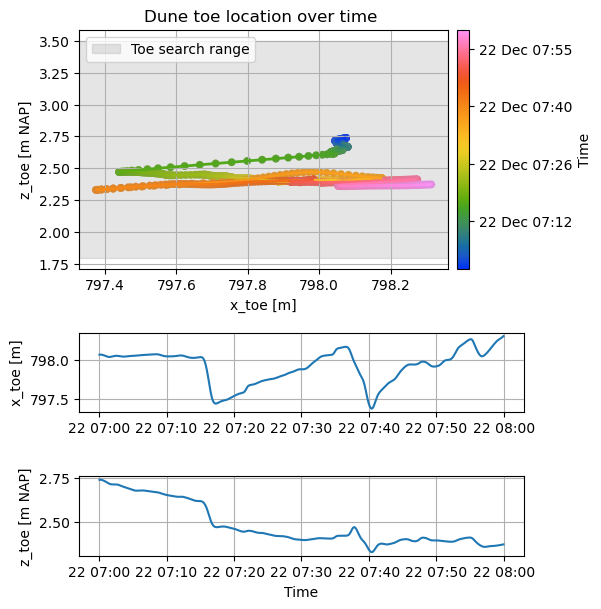

In [137]:
# Plot toe location evolution over time ------------
t1 = pd.Timestamp('19-12-2024 12:00') 
t2 = pd.Timestamp('19-12-2024 22:00') 
t1 = pd.Timestamp('22-12-2024 07:00') 
t2 = pd.Timestamp('22-12-2024 08:00') 

ds_plot = ds_filter_v5.sel(t=slice(t1,t2))

fig, axs = plt.subplots(3,1, figsize=(6, 6),     gridspec_kw={"height_ratios": [3, 1, 1]})

# Get toe coordinates and times
x_toe = ds_plot.x_toe_new.values
z_toe = ds_plot.z_toe_new.values
# use the datetime coordinate from the dataset
times = pd.to_datetime(ds_plot.t.values)

# Mask out invalid entries
valid = ~(np.isnan(x_toe) | np.isnan(z_toe)) # valid if both x_toe and z_toe are finite
if valid.sum() == 0:
    raise RuntimeError('No valid toe points to plot')

x_toe = x_toe[valid]
z_toe = z_toe[valid]
z_crest = ds_plot.z_crest.values[valid]
times = times[valid]

# Map datetimes to numeric for colormap scaling
time_nums = mdates.date2num(times)
norm = mcolors.Normalize(vmin=time_nums.min(), vmax=time_nums.max())

ax = axs[0]
# Plot colored line using LineCollection so color varies with time
points = np.array([x_toe, z_toe]).T
segments = np.concatenate([points[:-1, None, :], points[1:, None, :]], axis=1)
cmap = plt.get_cmap('cet_CET_R1')
lc = LineCollection(segments, cmap=cmap, norm=norm)

# associate each segment with the time of its starting point
lc.set_array(time_nums[:-1])
lc.set_linewidth(2)
ax.add_collection(lc)

# Scatter points colored by time
sc = ax.scatter(x_toe, z_toe, c=time_nums, cmap=cmap, norm=norm, s=30, linewidth=0.2)

# Colorbar with readable datetime labels
cb = fig.colorbar(lc, ax=ax, pad=0.02)
# convert ticks to human-readable datetimes
tick_locs = cb.get_ticks()
tick_labels = [mdates.num2date(t).strftime('%d %b %H:%M') for t in tick_locs]
cb.ax.set_yticklabels(tick_labels)
cb.set_label('Time')

# Highlight toe search range
ax.axhspan(z_min_toe, z_max_toe, alpha=0.2, color='gray', label=f'Toe search range')

ax.set_xlabel('x_toe [m]')
ax.set_ylabel('z_toe [m NAP]')
ax.set_title('Dune toe location over time ')
ax.grid()
ax.legend(loc='upper left')

# autoscale view to include LineCollection
ax.autoscale()
plt.tight_layout()

ax = axs[1]
ax.plot(times, x_toe, '-', label='x_toe')
ax.set_ylabel('x_toe [m]')
ax.grid()

ax = axs[2]
ax.plot(times, z_toe, '-', label='z_toe')
ax.set_xlabel('Time')
ax.set_ylabel('z_toe [m NAP]')
ax.grid()
folder = r"C:\Users\dpoppema\OneDrive - Delft University of Technology\PostDoc Hybrid dunes\Data experiment\Figures Lidar\Dune profiles, toe"
filename = f"Smoothed toe evolution S{n_lidar} storm{n_storm}.png"
#plt.savefig(os.path.join(folder, filename), dpi=300)

plt.show()

# fig, ax = plt.subplots(figsize=(8, 4))
# ax.plot(times, z_toe, '-o', label='z_toe')

C:\Users\dpoppema\AppData\Local\Temp\ipykernel_5724\27267815.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.ax.set_yticklabels(tick_labels)


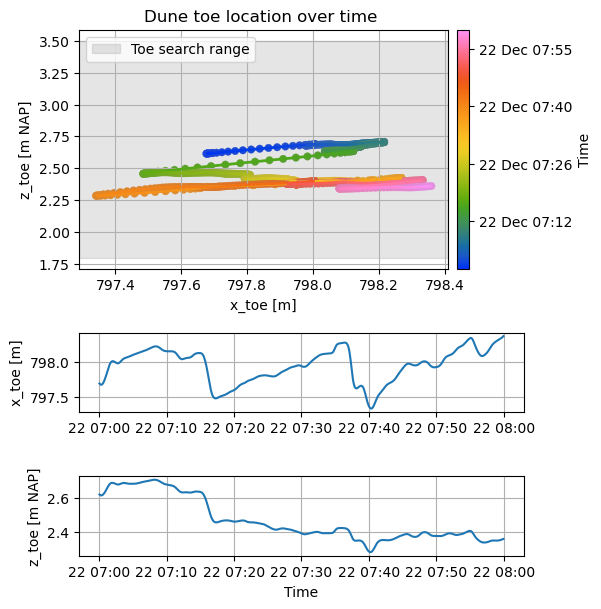

In [141]:
# Plot toe location evolution over time ------------
t1 = pd.Timestamp('19-12-2024 12:00') 
t2 = pd.Timestamp('19-12-2024 22:00') 
t1 = pd.Timestamp('22-12-2024 07:00') 
t2 = pd.Timestamp('22-12-2024 08:00') 

ds_plot = ds_filter_v5.sel(t=slice(t1,t2))

fig, axs = plt.subplots(3,1, figsize=(6, 6),     gridspec_kw={"height_ratios": [3, 1, 1]})

# Get toe coordinates and times
x_toe = ds_plot.x_toe_new.values
z_toe = ds_plot.z_toe_new.values
# use the datetime coordinate from the dataset
times = pd.to_datetime(ds_plot.t.values)

# Mask out invalid entries
valid = ~(np.isnan(x_toe) | np.isnan(z_toe)) # valid if both x_toe and z_toe are finite
if valid.sum() == 0:
    raise RuntimeError('No valid toe points to plot')

x_toe = x_toe[valid]
z_toe = z_toe[valid]
z_crest = ds_plot.z_crest.values[valid]
times = times[valid]

# Map datetimes to numeric for colormap scaling
time_nums = mdates.date2num(times)
norm = mcolors.Normalize(vmin=time_nums.min(), vmax=time_nums.max())

ax = axs[0]
# Plot colored line using LineCollection so color varies with time
points = np.array([x_toe, z_toe]).T
segments = np.concatenate([points[:-1, None, :], points[1:, None, :]], axis=1)
cmap = plt.get_cmap('cet_CET_R1')
lc = LineCollection(segments, cmap=cmap, norm=norm)

# associate each segment with the time of its starting point
lc.set_array(time_nums[:-1])
lc.set_linewidth(2)
ax.add_collection(lc)

# Scatter points colored by time
sc = ax.scatter(x_toe, z_toe, c=time_nums, cmap=cmap, norm=norm, s=30, linewidth=0.2)

# Colorbar with readable datetime labels
cb = fig.colorbar(lc, ax=ax, pad=0.02)
# convert ticks to human-readable datetimes
tick_locs = cb.get_ticks()
tick_labels = [mdates.num2date(t).strftime('%d %b %H:%M') for t in tick_locs]
cb.ax.set_yticklabels(tick_labels)
cb.set_label('Time')

# Highlight toe search range
ax.axhspan(z_min_toe, z_max_toe, alpha=0.2, color='gray', label=f'Toe search range')

ax.set_xlabel('x_toe [m]')
ax.set_ylabel('z_toe [m NAP]')
ax.set_title('Dune toe location over time ')
ax.grid()
ax.legend(loc='upper left')

# autoscale view to include LineCollection
ax.autoscale()
plt.tight_layout()

ax = axs[1]
ax.plot(times, x_toe, '-', label='x_toe')
ax.set_ylabel('x_toe [m]')
ax.grid()

ax = axs[2]
ax.plot(times, z_toe, '-', label='z_toe')
ax.set_xlabel('Time')
ax.set_ylabel('z_toe [m NAP]')
ax.grid()
folder = r"C:\Users\dpoppema\OneDrive - Delft University of Technology\PostDoc Hybrid dunes\Data experiment\Figures Lidar\Dune profiles, toe"
filename = f"Smoothed toe evolution S{n_lidar} storm{n_storm}.png"
#plt.savefig(os.path.join(folder, filename), dpi=300)

plt.show()

# fig, ax = plt.subplots(figsize=(8, 4))
# ax.plot(times, z_toe, '-o', label='z_toe')

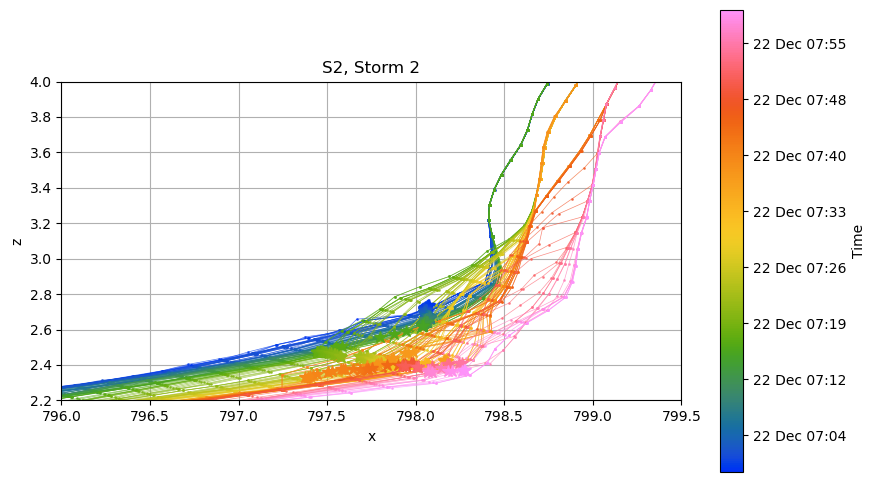

In [143]:
t1 = pd.Timestamp('2024-12-18 12:45') 
t2 = pd.Timestamp('2024-12-18 16:15') 
t1 = pd.Timestamp('2024-12-22 7:00') 
t2 = pd.Timestamp('2024-12-22 08:00') 
#t1 = np.datetime64('2025-01-01T15:00')
#t2 = np.datetime64('2025-01-01T16:00')

ds_plot = ds_filter_v5.sel(t=slice(t1, t2))  # select specific time range for plotting

# keep only timesteps with non-nan x
t_keep = ds_plot.t.values[~np.isnan(ds_plot.x.values).all(axis=0)]  # keep timesteps where not all x are nan
ds_plot = ds_plot.sel(t=t_keep)  # select only those timesteps

# prepare colormap normalized to time
times = pd.to_datetime(ds_plot.t.values)
times_num = mdates.date2num(times)
norm = mpl.colors.Normalize(vmin=times_num.min(), vmax=times_num.max())
cmap = plt.cm.viridis

cmap = plt.get_cmap('cet_CET_R1')

# optional: subsample time steps to avoid overplotting
n_steps = ds_plot.sizes['t']
step = 1#max(1, n_steps // 1000)  # plot up to ~400 lines

fig, ax = plt.subplots(figsize=(10,6))
x_prev = None
z_prev = None

# plot lines on ax 
for j in range(0, n_steps, step):
    x = ds_plot.x.values[:, j]
    z = ds_plot.z.values[:, j]
    mask = ~np.isnan(x) & ~np.isnan(z)
    if mask.sum() < 2:
        continue
    if x_prev is not None:
        dL = np.sqrt((x[mask] - x_prev[mask])**2 + (z[mask] - z_prev[mask])**2)
        if np.nanmax(dL) < 0.01:  # skip profiles almost identical to previous one, ignoring NaNs
            continue

    color = cmap(norm(times_num[j]))
    ax.plot(x[mask], z[mask], '-o',color=color, linewidth=0.5, alpha=0.7, markersize=1)
    x_prev = x.copy()
    z_prev = z.copy()

for j in range(0, n_steps, step):
    color = cmap(norm(times_num[j]))
    ax.plot(ds_plot.x_toe_new.values[j], ds_plot.z_toe_new.values[j], '*', markersize=9, color=color)  # plot toe location for this profile
    #ax.plot(ds_plot.x_toe.values[j], ds_plot.z_toe.values[j], '*', markersize=9, color=color)  # plot toe location for this profile
    #ax.plot(ds_plot.x_crest.values[j], ds_plot.z_crest.values[j], '*', markersize=9, color=color)  # plot crest location for this profile


# create mappable and attach colorbar to the axes
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])                    # required for colorbar
cbar = fig.colorbar(sm, ax=ax, label='Time')
cbar.ax.yaxis_date()
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))

ax.set_xlabel('x'); ax.set_ylabel('z')
ax.set_xlim([796, 799.5])
ax.set_ylim([2.2, 4])

ax.grid()
ax.set_aspect('equal', adjustable='box')
ax.set_title(f"S{n_lidar}, Storm {n_storm}")

filename = f"Dune profiles with toe -  S{n_lidar} storm{n_storm}.png"
#plt.savefig(os.path.join(folder, filename), dpi=200)

plt.show()


In [32]:
# Save the filled dataset to a new NetCDF file
# Encoding: compress all variables and dimensions with deflate4
compression = {var: {"zlib": True, "complevel": 4} for var in list(ds_filter_v5.data_vars) + list(ds_filter_v5.coords)}  # temporary dict, with only compression settings
folder = r'C:\Users\dpoppema\OneDrive - Delft University of Technology\PostDoc Hybrid dunes\Data experiment'
filename = f"profiles_5s_ds_filter_v5_filled_S{n_lidar}_storm{n_storm} medium.nc" 
ds_filter_v5.to_netcdf(os.path.join(folder, filename), encoding=compression)